In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [4]:
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


In [5]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=1000, shuffle=False)

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
model = CNN().to(device)

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [17]:

epochs = 10
model_loss=[]
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")
    model_loss.append(total_loss/len(train_loader))


Epoch 1/10, Loss: 0.0044
Epoch 2/10, Loss: 0.0009
Epoch 3/10, Loss: 0.0035
Epoch 4/10, Loss: 0.0035
Epoch 5/10, Loss: 0.0027
Epoch 6/10, Loss: 0.0011
Epoch 7/10, Loss: 0.0044
Epoch 8/10, Loss: 0.0017
Epoch 9/10, Loss: 0.0023
Epoch 10/10, Loss: 0.0024


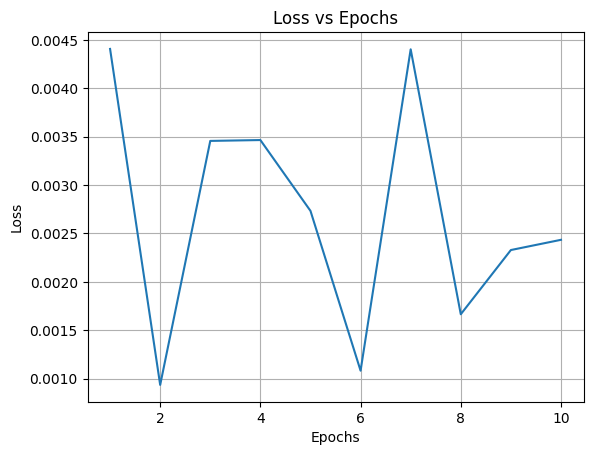

In [21]:
import matplotlib.pyplot as plt

ep=list(range(1,11))
plt.plot(ep,model_loss)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.title('Loss vs Epochs')
plt.show()

In [23]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 99.18%


In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {acc * 100:.2f}%")

Accuracy: 99.18%


In [26]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9959    0.9980    0.9969       980
           1     0.9956    0.9965    0.9960      1135
           2     0.9922    0.9893    0.9908      1032
           3     0.9950    0.9941    0.9946      1010
           4     0.9878    0.9908    0.9893       982
           5     0.9812    0.9944    0.9878       892
           6     0.9968    0.9896    0.9932       958
           7     0.9893    0.9893    0.9893      1028
           8     0.9969    0.9846    0.9907       974
           9     0.9862    0.9911    0.9886      1009

    accuracy                         0.9918     10000
   macro avg     0.9917    0.9918    0.9917     10000
weighted avg     0.9918    0.9918    0.9918     10000



In [27]:
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[ 978    0    0    0    0    0    1    1    0    0]
 [   0 1131    0    0    0    2    1    1    0    0]
 [   1    1 1021    0    1    0    0    8    0    0]
 [   0    0    0 1004    0    5    0    0    1    0]
 [   0    0    0    0  973    0    0    0    0    9]
 [   0    0    0    3    0  887    1    0    1    0]
 [   1    3    0    0    2    4  948    0    0    0]
 [   0    0    4    1    3    0    0 1017    1    2]
 [   2    1    4    1    1    3    0    0  959    3]
 [   0    0    0    0    5    3    0    1    0 1000]]


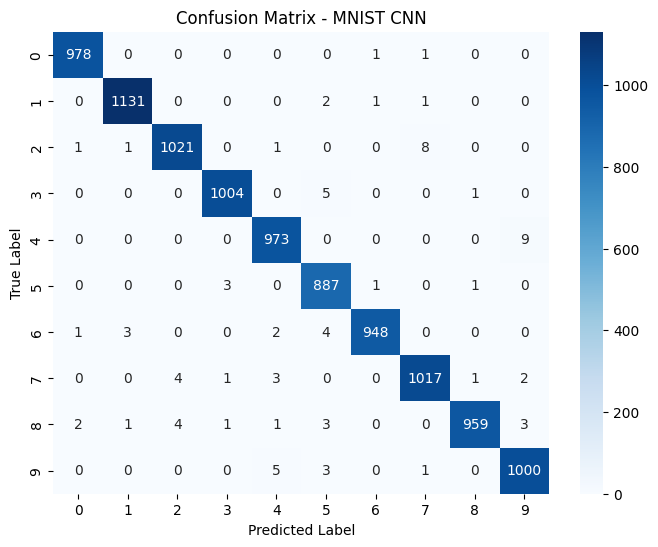

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MNIST CNN')
plt.show()

In [29]:
model.to(device)
torch.save(model.state_dict(), 'mnist_cnn_model.pth')